In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.optimize import linprog
from scipy.special import gammaln

In [2]:
CSV_PATH = Path("genesis_scan_table.csv")

TRAIN_FRAC = 0.80
SEED = 1234
TAU_B = -1.0

In [3]:
def log_base_and_logc(alpha, d, kappa, tau_b=1.0):
    A = 3.0 * (1.0 + d) ** 2
    s = np.exp(d * np.log(kappa))
    nu = np.sqrt(2.25 + A * s * (1.0 - s))

    u = A * (1.0 - s) / (nu + 1.5)
    rootA = np.sqrt(A)

    I = (
        3.0
        + rootA * np.arctan(u / rootA)
        + 1.5 * np.log(A / (A + u**2))
        - A * (3.0 + u) / (A + u**2)
    )

    log_base = (
        -np.log(4.0 * np.pi**2 * tau_b**2 * alpha)
        - 2.0 * (1.0 + d) / d
        + 2.0 * I / d
    )

    logC = (2.0 * nu - 3.0) * np.log(2.0) + 2.0 * (
        gammaln(nu) - gammaln(1.5)
    )
    return log_base, logC


def predict_log_ps(df, params, tau_b=1.0):
    a, b, q = params
    alpha = df["alpha"].to_numpy(float)
    d = df["d"].to_numpy(float)
    kappa = df["kappa"].to_numpy(float)

    log_base, logC = log_base_and_logc(alpha, d, kappa, tau_b=tau_b)
    return log_base + a + b * d + q * logC

In [4]:
def split_by_d_kappa(df, train_frac=0.8, seed=1234):
    pair_id = pd.factorize(pd.MultiIndex.from_frame(df[["d", "kappa"]]))[0]
    unique_ids = np.arange(pair_id.max() + 1)

    rng = np.random.default_rng(seed)
    rng.shuffle(unique_ids)

    train_ids = unique_ids[: int(train_frac * len(unique_ids))]
    train_mask = np.isin(pair_id, train_ids)

    return df.loc[train_mask].copy(), df.loc[~train_mask].copy()


def fit_minimax_log_error(df, tau_b=1.0):
    alpha = df["alpha"].to_numpy(float)
    d = df["d"].to_numpy(float)
    kappa = df["kappa"].to_numpy(float)
    log_ps = np.log(df["Ps"].to_numpy(float))

    log_base, logC = log_base_and_logc(alpha, d, kappa, tau_b=tau_b)
    y = log_ps - log_base

    n = len(df)
    X = sparse.csr_matrix(np.column_stack([np.ones(n), d, logC]))
    minus_t = sparse.csr_matrix(-np.ones((n, 1)))

    A_ub = sparse.vstack(
        [sparse.hstack([X, minus_t]), sparse.hstack([-X, minus_t])],
        format="csr",
    )
    b_ub = np.concatenate([y, -y])

    res = linprog(
        c=np.array([0.0, 0.0, 0.0, 1.0]),
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=[(None, None), (None, None), (None, None), (0.0, None)],
        method="highs",
    )

    return res.x[:3], res.x[3]


def evaluate(df, params, tau_b=1.0):
    log_true = np.log(df["Ps"].to_numpy(float))
    log_pred = predict_log_ps(df, params, tau_b=tau_b)

    abs_rel_error_percent = 100.0 * np.abs(np.expm1(log_pred - log_true))

    return {
        "mean_error_percent": abs_rel_error_percent.mean(),
        "max_error_percent": abs_rel_error_percent.max(),
    }


In [5]:
df = pd.read_csv(CSV_PATH, usecols=["alpha", "d", "kappa", "Ps"])

train, verify = split_by_d_kappa(df, train_frac=TRAIN_FRAC, seed=SEED)
params, train_minimax_log_error = fit_minimax_log_error(train, tau_b=TAU_B)

a, b, q = params
train_stats = evaluate(train, params, tau_b=TAU_B)
verify_stats = evaluate(verify, params, tau_b=TAU_B)

print(f"Loaded rows: {len(df):,}")
print(f"Training rows: {len(train):,}")
print(f"Verification rows: {len(verify):,}")
print()
print("Fitted parameters:")
print(f"a = {a:.12g}")
print(f"b = {b:.12g}")
print(f"q = {q:.12g}")

Loaded rows: 512,000
Training rows: 409,600
Verification rows: 102,400

Fitted parameters:
a = 0.0167018906314
b = -0.283027102799
q = 1.31920847627


In [6]:
stats = pd.DataFrame(
    {
        "training": train_stats,
        "verification": verify_stats,
    }
).round(4)
stats


,training,verification
mean_error_percent,0.1088,0.1092
max_error_percent,0.3284,0.3277


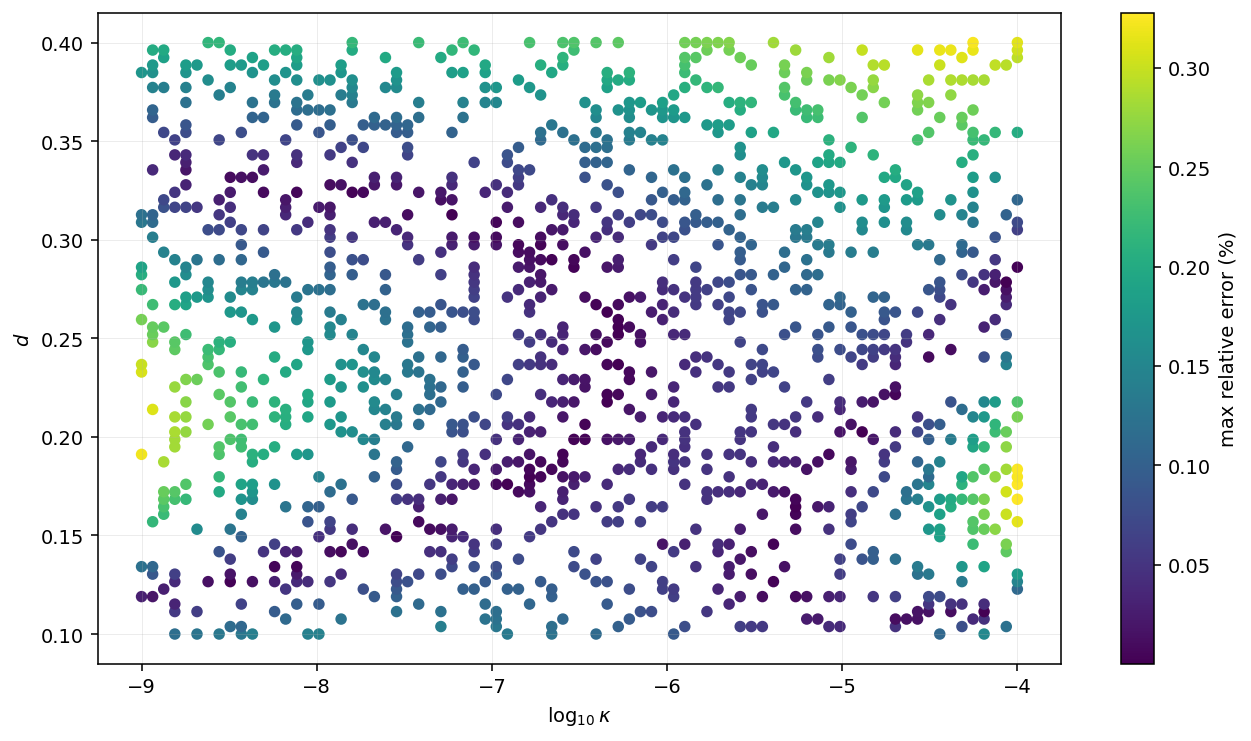

In [7]:
def pair_loss_table(df_eval, params, tau_b=1.0):
    tmp = df_eval[["alpha", "d", "kappa", "Ps"]].copy()
    log_true = np.log(tmp["Ps"].to_numpy(float))
    log_pred = predict_log_ps(tmp, params, tau_b=tau_b)

    tmp["loss_percent"] = 100.0 * np.abs(np.expm1(log_pred - log_true))

    return (
        tmp.groupby(["d", "kappa"], as_index=False)["loss_percent"]
        .max()
        .assign(log10_kappa=lambda x: np.log10(x["kappa"]))
    )


def plot_verification_loss_heatmap(pair_loss, output_path=None):
    fig, ax = plt.subplots(figsize=(9.5, 5.4), dpi=140)

    sc = ax.scatter(
        pair_loss["log10_kappa"],
        pair_loss["d"],
        c=pair_loss["loss_percent"],
        s=24,
    )

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("max relative error (%)")

    ax.set_xlabel(r"$\log_{10}\kappa$")
    ax.set_ylabel(r"$d$")
    ax.grid(True, linewidth=0.3, alpha=0.4)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")

    return fig, ax


verify_pair_loss = pair_loss_table(verify, params, tau_b=TAU_B)
fig, ax = plot_verification_loss_heatmap(
    verify_pair_loss,
    output_path="verification_loss.png",
)
plt.show()

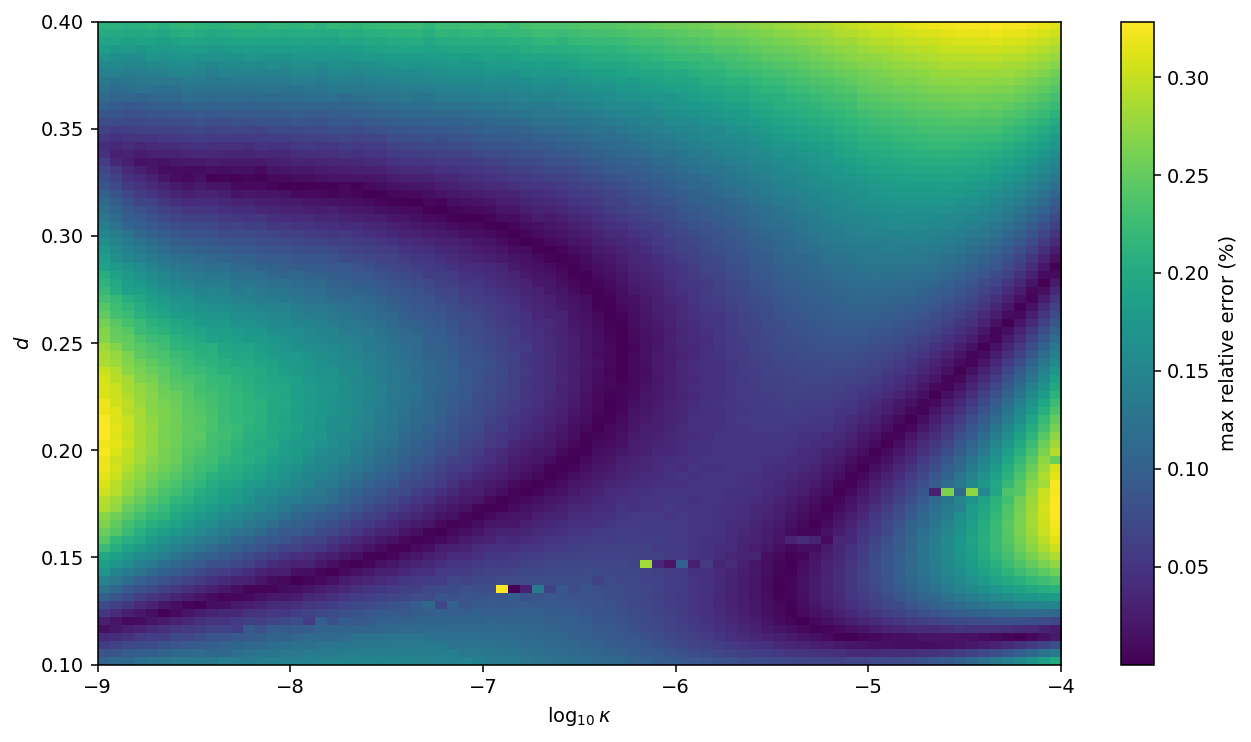

In [8]:
def plot_full_grid_loss_heatmap(df_eval, params, output_path=None, tau_b=1.0):
    pair_loss = pair_loss_table(df_eval, params, tau_b=tau_b)
    grid = pair_loss.pivot(index="d", columns="log10_kappa", values="loss_percent")

    fig, ax = plt.subplots(figsize=(9.5, 5.4), dpi=140)

    im = ax.imshow(
        grid.to_numpy(),
        origin="lower",
        aspect="auto",
        extent=[
            grid.columns.min(),
            grid.columns.max(),
            grid.index.min(),
            grid.index.max(),
        ],
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("max relative error (%)")

    ax.set_xlabel(r"$\log_{10}\kappa$")
    ax.set_ylabel(r"$d$")

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")

    return fig, ax


fig, ax = plot_full_grid_loss_heatmap(
    df,
    params,
    output_path="full_loss.png",
    tau_b=TAU_B,
)
plt.show()